In [ ]:
# 1. Imports
# Bibliothèque pour manipuler des tableaux de données
import pandas as pd

# Bibliothèque pour les calculs numériques
import numpy as np

# Bibliothèques pour les graphiques
import matplotlib.pyplot as plt
import seaborn as sns

# Outil pour transformer automatiquement le texte en nombres
from sklearn.feature_extraction.text import CountVectorizer

# Outil pour séparer les données en train / test
from sklearn.model_selection import train_test_split

# Outils pour évaluer le modèle
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Sauvegarde du vectorizer
import joblib

# PyTorch
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

In [ ]:
# 2. Création des données
data = [
    ("alice", "gagnez un cadeau gratuit maintenant", 1),
    ("alice", "bonjour voici le rapport du projet", 0),
    ("karim", "urgent cliquez ici pour gagner un iphone", 1),
    ("karim", "reunion demain avec le client", 0),
    ("sophie", "promotion gratuite offre exceptionnelle", 1),
    ("sophie", "voici le compte rendu de la reunion", 0),
    ("nina", "vous avez gagne un cadeau", 1),
    ("nina", "merci pour votre retour sur le dossier", 0),
    ("paul", "cliquez vite offre limitee gratuite", 1),
    ("paul", "bonjour pouvez vous valider le document", 0),
    ("amina", "argent facile gagnez rapidement", 1),
    ("amina", "planning de formation mis a jour", 0),
    ("luc", "offre speciale cliquez maintenant", 1),
    ("luc", "rapport mensuel disponible", 0),
    ("emma", "felicitations vous avez gagne", 1),
    ("emma", "reunion equipe a 14h", 0),
    ("mehdi", "urgent votre compte est bloque cliquez ici", 1),
    ("mehdi", "merci de confirmer votre presence demain", 0),
    ("sarah", "cadeau gratuit offre reservee aux gagnants", 1),
    ("sarah", "voici les documents demandes", 0),
    ("yassine", "gagnez de argent facilement maintenant", 1),
    ("yassine", "le support de cours est disponible", 0),
    ("lea", "cliquez maintenant pour obtenir votre cadeau", 1),
    ("lea", "bonjour voici le compte rendu", 0),
    ("omar", "offre gratuite limitee cliquez vite", 1),
    ("omar", "rendez vous client confirme", 0),
    ("claire", "vous avez gagne une promotion exclusive", 1),
    ("claire", "merci pour votre email", 0),
    ("hugo", "urgent gagnez un telephone gratuit", 1),
    ("hugo", "rapport projet finalise", 0),
]

# Transformation en DataFrame pandas
df = pd.DataFrame(data, columns=["destinataire", "email", "label"])

print("Aperçu des données :")
display(df.head())

print("\nNombre total d'emails :", len(df))



Aperçu des données :


,destinataire,email,label
0,alice,gagnez un cadeau gratuit maintenant,1
1,alice,bonjour voici le rapport du projet,0
2,karim,urgent cliquez ici pour gagner un iphone,1
3,karim,reunion demain avec le client,0
4,sophie,promotion gratuite offre exceptionnelle,1



Nombre total d'emails : 30



Répartition des labels :
label
1    15
0    15
Name: count, dtype: int64
  destinataire                                     email  label type_email
0        alice       gagnez un cadeau gratuit maintenant      1       spam
1        alice        bonjour voici le rapport du projet      0     normal
2        karim  urgent cliquez ici pour gagner un iphone      1       spam
3        karim             reunion demain avec le client      0     normal
4       sophie   promotion gratuite offre exceptionnelle      1       spam


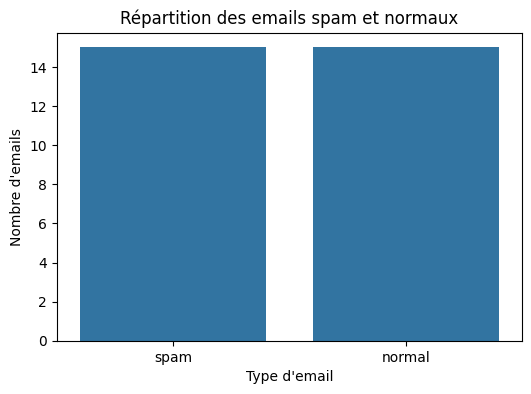

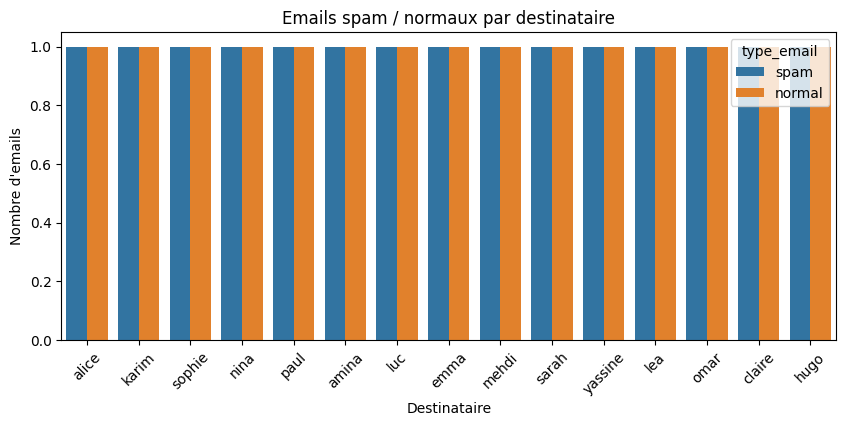

In [ ]:
# graphique
print("\nRépartition des labels :")
print(df["label"].value_counts())
# Création d'une colonne plus lisible pour les graphiques
df["type_email"] = df["label"].map({
    0: "normal",
    1: "spam"
})
print(df.head())
# Graphique de répartition spam / normal
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="type_email")
plt.title("Répartition des emails spam et normaux")
plt.xlabel("Type d'email")
plt.ylabel("Nombre d'emails")
plt.show()

plt.figure(figsize=(10, 4))
sns.countplot(data=df, x="destinataire", hue="type_email")
plt.title("Emails spam / normaux par destinataire")
plt.xlabel("Destinataire")
plt.ylabel("Nombre d'emails")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# 4. Vectorisation
vectorizer = CountVectorizer()

# Textes des emails
X_text = df["email"]
print(X_text.head())

# Labels : 1 spam, 0 normal
y = df["label"].values
print(y)

# Transformation des emails en matrice numérique
X = vectorizer.fit_transform(X_text).toarray()

# On récupère les mots détectés automatiquement
mots = vectorizer.get_feature_names_out()

# On affiche la matrice sous forme de DaFratame lisible
df_matrice = pd.DataFrame(X, columns=mots)

# Affichage
display(df_matrice.head())

# On ajoute l'email original pour comprendre la correspondance
df_matrice.insert(0, "email_original", X_text.values)

# Affichage
display(df_matrice.head())


print("\nMots détectés automatiquement :")
print(mots)


# On ajoute aussi le label pour voir spam / normal
df_matrice["label"] = y

# Affichage
display(df_matrice.head())

print("\nShape de X :", X.shape)
print("Shape de y :", y.shape)




0         gagnez un cadeau gratuit maintenant
1          bonjour voici le rapport du projet
2    urgent cliquez ici pour gagner un iphone
3               reunion demain avec le client
4     promotion gratuite offre exceptionnelle
Name: email, dtype: object
[1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0 1 0]


,14h,argent,aux,avec,avez,bloque,bonjour,cadeau,client,cliquez,...,sur,telephone,un,une,urgent,valider,vite,voici,votre,vous
0,0,0,0,0,0,0,0,1,0,0,...,0,0,1,0,0,0,0,0,0,0
1,0,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
2,0,0,0,0,0,0,0,0,0,1,...,0,0,1,0,1,0,0,0,0,0
3,0,0,0,1,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


,email_original,14h,argent,aux,avec,avez,bloque,bonjour,cadeau,client,...,sur,telephone,un,une,urgent,valider,vite,voici,votre,vous
0,gagnez un cadeau gratuit maintenant,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,0,0,0,0
1,bonjour voici le rapport du projet,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,urgent cliquez ici pour gagner un iphone,0,0,0,0,0,0,0,0,0,...,0,0,1,0,1,0,0,0,0,0
3,reunion demain avec le client,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,promotion gratuite offre exceptionnelle,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0



Mots détectés automatiquement :
['14h' 'argent' 'aux' 'avec' 'avez' 'bloque' 'bonjour' 'cadeau' 'client'
 'cliquez' 'compte' 'confirme' 'confirmer' 'cours' 'de' 'demain'
 'demandes' 'disponible' 'document' 'documents' 'dossier' 'du' 'email'
 'equipe' 'est' 'exceptionnelle' 'exclusive' 'facile' 'facilement'
 'felicitations' 'finalise' 'formation' 'gagnants' 'gagne' 'gagner'
 'gagnez' 'gratuit' 'gratuite' 'ici' 'iphone' 'jour' 'la' 'le' 'les'
 'limitee' 'maintenant' 'mensuel' 'merci' 'mis' 'obtenir' 'offre'
 'planning' 'pour' 'pouvez' 'presence' 'projet' 'promotion' 'rapidement'
 'rapport' 'rendez' 'rendu' 'reservee' 'retour' 'reunion' 'speciale'
 'support' 'sur' 'telephone' 'un' 'une' 'urgent' 'valider' 'vite' 'voici'
 'votre' 'vous']


,email_original,14h,argent,aux,avec,avez,bloque,bonjour,cadeau,client,...,telephone,un,une,urgent,valider,vite,voici,votre,vous,label
0,gagnez un cadeau gratuit maintenant,0,0,0,0,0,0,0,1,0,...,0,1,0,0,0,0,0,0,0,1
1,bonjour voici le rapport du projet,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,urgent cliquez ici pour gagner un iphone,0,0,0,0,0,0,0,0,0,...,0,1,0,1,0,0,0,0,0,1
3,reunion demain avec le client,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,promotion gratuite offre exceptionnelle,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1



Shape de X : (30, 76)
Shape de y : (30,)


In [ ]:
# 5. Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("\nFormes après séparation train / test :")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)


Formes après séparation train / test :
X_train : (22, 76)
X_test  : (8, 76)
y_train : (22,)
y_test  : (8,)


In [ ]:
# 6. Tenseurs PyTorch
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)

y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

print("\nAvant unsqueeze :")
print("y_train_tensor shape =", y_train_tensor.shape)
print("y_test_tensor shape  =", y_test_tensor.shape)

# Le modèle va produire une sortie de forme [nombre_exemples, 1].
# On transforme donc y en colonne :
#
# avant : [nombre_exemples]
# après : [nombre_exemples, 1]
y_train_tensor = y_train_tensor.unsqueeze(1)
y_test_tensor = y_test_tensor.unsqueeze(1)

print("\nAprès unsqueeze(1) :")
print("y_train_tensor shape =", y_train_tensor.shape)
print("y_test_tensor shape  =", y_test_tensor.shape)





Avant unsqueeze :
y_train_tensor shape = torch.Size([22])
y_test_tensor shape  = torch.Size([8])

Après unsqueeze(1) :
y_train_tensor shape = torch.Size([22, 1])
y_test_tensor shape  = torch.Size([8, 1])


In [ ]:
# 7. DataLoader
# TensorDataset associe chaque email X avec son label y.
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)

# DataLoader découpe les données en batchs.
# batch_size=4 signifie que le modèle reçoit 4 emails à la fois.
train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True
)

# On affiche un batch pour comprendre les dimensions.
for batch_X, batch_y in train_loader:
    print("\nExemple de batch :")
    print("batch_X shape :", batch_X.shape)
    print("batch_y shape :", batch_y.shape)



Exemple de batch :
batch_X shape : torch.Size([4, 76])
batch_y shape : torch.Size([4, 1])

Exemple de batch :
batch_X shape : torch.Size([4, 76])
batch_y shape : torch.Size([4, 1])

Exemple de batch :
batch_X shape : torch.Size([4, 76])
batch_y shape : torch.Size([4, 1])

Exemple de batch :
batch_X shape : torch.Size([4, 76])
batch_y shape : torch.Size([4, 1])

Exemple de batch :
batch_X shape : torch.Size([4, 76])
batch_y shape : torch.Size([4, 1])

Exemple de batch :
batch_X shape : torch.Size([2, 76])
batch_y shape : torch.Size([2, 1])


In [ ]:
# 8. Modèle PyTorch
# input_dim correspond au nombre de mots détectés par CountVectorizer.
input_dim = X_train.shape[1]

class SpamClassifier(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        # Couche cachée :
        # elle reçoit le vecteur représentant l'email.
        self.hidden = nn.Linear(input_dim, 8)

        # Fonction d'activation ReLU :
        # elle aide le modèle à apprendre des relations non linéaires.
        self.relu = nn.ReLU()

        # Couche de sortie :
        # elle produit une seule valeur.
        self.output = nn.Linear(8, 1)

        # Sigmoid :
        # transforme la sortie en probabilité entre 0 et 1.
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.hidden(x)
        x = self.relu(x)
        x = self.output(x)
        x = self.sigmoid(x)
        return x

# Création du modèle
model = SpamClassifier(input_dim)

print("\nArchitecture du modèle :")
print(model)



Architecture du modèle :
SpamClassifier(
  (hidden): Linear(in_features=76, out_features=8, bias=True)
  (relu): ReLU()
  (output): Linear(in_features=8, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [ ]:
# 9. Loss et optimizer
# BCELoss est adaptée à une classification binaire :
# spam / normal.
criterion = nn.BCELoss()

# Adam est l'optimizer.
# Il corrige les poids du modèle à partir des gradients.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [ ]:
# 10. Entraînement
epochs = 80

loss_history = []
accuracy_history = []

for epoch in range(epochs):

    # Mode entraînement
    model.train()

    total_loss = 0
    all_predictions = []
    all_labels = []

    for batch_X, batch_y in train_loader:

        # 1. Forward : le modèle prédit
        predictions = model(batch_X)

        # 2. Loss : on mesure l'erreur
        loss = criterion(predictions, batch_y)

        # 3. On remet les anciens gradients à zéro
        optimizer.zero_grad()

        # 4. Backward : PyTorch calcule les gradients
        loss.backward()

        # 5. Step : l'optimizer corrige les poids
        optimizer.step()

        # Mémorisation de la loss
        total_loss += loss.item()

        # Transformation des probabilités en classes 0 ou 1
        predicted_classes = (predictions >= 0.5).float()
        # detach() permet de détacher les tenseurs du graphe de calcul je reviens
        # a des tableaux numpy()
        all_predictions.extend(predicted_classes.detach().numpy())
        all_labels.extend(batch_y.detach().numpy())

    # Loss moyenne sur l'epoch
    avg_loss = total_loss / len(train_loader)

    # Accuracy sur l'epoch
    acc = accuracy_score(all_labels, all_predictions)

    loss_history.append(avg_loss)
    accuracy_history.append(acc)

    if epoch % 10 == 0:
        print(f"Epoch {epoch:03d} | Loss = {avg_loss:.4f} | Accuracy = {acc:.4f}")


Epoch 000 | Loss = 0.6865 | Accuracy = 0.5000
Epoch 010 | Loss = 0.3227 | Accuracy = 1.0000
Epoch 020 | Loss = 0.2176 | Accuracy = 1.0000
Epoch 030 | Loss = 0.1436 | Accuracy = 1.0000
Epoch 040 | Loss = 0.1072 | Accuracy = 1.0000
Epoch 050 | Loss = 0.0828 | Accuracy = 1.0000
Epoch 060 | Loss = 0.0656 | Accuracy = 1.0000
Epoch 070 | Loss = 0.0488 | Accuracy = 1.0000


In [ ]:
# 15. API